# Task 12 – Week 7: Hyperparameter Sensitivity Analysis

Sweeps 6 hyperparameters of the 13-band retrieval pipeline on EuroSAT fold 0:
- **σ** (query alignment temperature): [0.1, 0.3, 0.5, 0.7, 1.0]
- **τ** (affinity softmax temperature): [0.05, 0.1, 0.2, 0.5]
- **λ_m** (manifold loss weight): [0.01, 0.05, 0.1, 0.2]
- **k** (k-NN neighbors): [3, 5, 7, 10]
- **num_steps** (optimization steps): [1, 3, 5, 7, 10]
- **lr** (learning rate): [0.005, 0.01, 0.02, 0.05]

**Outputs**: `results/hyperparameter_sensitivity/`
- `sensitivity_raw.csv` — 26 rows
- `sensitivity_summary.csv` — 6 rows, one per hyperparameter
- `sensitivity_<param>.png` — 6 individual curves (300 DPI)
- `sensitivity_all_6.png` — Figure 5 paper (2×3 grid)


## 1. Setup


In [21]:
import sys
from pathlib import Path

# Detect project root (works whether notebook is run from project root or notebooks/)
def _find_project_root(start: Path) -> Path:
    """Walk up until we find src/ directory (project root marker)."""
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir():
            return parent
    return start  # fallback

_nb_dir = Path.cwd()
PROJECT_ROOT = _find_project_root(_nb_dir)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Config — all paths anchored to PROJECT_ROOT
EUROSAT_ROOT   = PROJECT_ROOT / "data/EuroSAT_MS"
CHECKPOINT     = PROJECT_ROOT / "checkpoints/ViT-B-16.pt"
OUTPUT_DIR     = PROJECT_ROOT / "results/hyperparameter_sensitivity"   # always results/hyperparameter_sensitivity/
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FOLD_ID        = 0
OURS_SIGMA     = 0.5
OURS_TAU       = None
OURS_LAMBDA_M  = 0.1
OURS_K         = 5
OURS_NUM_STEPS = 5
OURS_LR        = 0.01

print(f"Project root:        {PROJECT_ROOT}")
print(f"Output dir:          {OUTPUT_DIR}")
print(f"PyTorch:             {torch.__version__}")
print(f"EuroSAT root exists: {EUROSAT_ROOT.exists()}")
print(f"Checkpoint exists:   {CHECKPOINT.exists()}")


Project root:        /Users/tienesng06/Desktop/ACIVS_ThayBach
Output dir:          /Users/tienesng06/Desktop/ACIVS_ThayBach/results/hyperparameter_sensitivity
PyTorch:             2.0.1
EuroSAT root exists: True
Checkpoint exists:   True


## 2. Smoke Test (optional — ~15 min, 2 values per param)


In [22]:
# Uncomment and run this cell first to validate the pipeline end-to-end
# !python scripts/run_hyperparameter_sensitivity.py \
#   --root data/EuroSAT_MS \
#   --checkpoint checkpoints/ViT-B-16.pt \
#   --fold-id 0 \
#   --smoke-test \
#   --output-dir results/hyperparameter_sensitivity

print("Skip smoke test → run full sweep in Cell 3")


Skip smoke test → run full sweep in Cell 3


## 3. Run Full Sensitivity Sweep (~4-5 hours)


In [23]:
# Run the full 26-experiment sweep
# Encodes band embeddings ONCE (~15 min), then sweeps 6 params (~3-4h)
# Results are saved incrementally after each param sweep.

import subprocess
result = subprocess.run([
    sys.executable, "scripts/run_hyperparameter_sensitivity.py",
    "--root",        str(EUROSAT_ROOT),
    "--checkpoint",  str(CHECKPOINT),
    "--fold-id",     str(FOLD_ID),
    "--output-dir",  str(OUTPUT_DIR),
    "--no-progress",  # set to False if running interactively
], capture_output=True, text=True)

print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])



STDERR: /Library/Frameworks/Python.framework/Versions/3.11/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/tienesng06/Desktop/ACIVS_ThayBach/notebooks/scripts/run_hyperparameter_sensitivity.py': [Errno 2] No such file or directory



## 4. Load Results


In [24]:
raw_csv     = OUTPUT_DIR / "sensitivity_raw.csv"
summary_csv = OUTPUT_DIR / "sensitivity_summary.csv"

df_raw     = pd.read_csv(raw_csv)
df_summary = pd.read_csv(summary_csv)

print(f"Raw results: {len(df_raw)} rows × {len(df_raw.columns)} cols")
df_raw


Raw results: 26 rows × 7 cols


,param_name,param_value,R@1,R@5,R@10,mAP,elapsed_ms
0,sigma,0.100,84.351850,96.148145,98.092592,45.345811,19388.0
1,sigma,0.300,84.425926,96.129632,98.111111,45.051006,18545.1
2,sigma,0.500,84.481484,96.296299,98.037034,45.019564,18199.2
3,sigma,0.700,84.407407,96.407408,98.092592,44.999823,18004.0
4,sigma,1.000,84.314817,96.388888,98.092592,44.988240,17469.6
5,tau,0.050,81.203705,95.370370,97.370368,38.219142,17277.2
6,tau,0.100,83.444446,95.777780,97.814816,41.170067,17760.6
7,tau,0.200,83.925927,96.129632,97.925925,43.121724,16599.5
8,tau,0.500,84.074074,96.240741,98.055553,44.634954,17858.6
9,lambda_m,0.010,84.481484,96.296299,98.037034,45.019531,17196.1


In [25]:
df_summary


,param,tested_values,best_value,best_R@1,best_R@10,R@1_range,robust
0,sigma,"[0.1, 0.3, 0.5, 0.7, 1.0]",0.50,84.48,98.04,0.17,Yes
1,tau,"[0.05, 0.1, 0.2, 0.5]",0.50,84.07,98.06,2.87,No
2,lambda_m,"[0.01, 0.05, 0.1, 0.2]",0.01,84.48,98.04,0.00,Yes
3,k,"[3, 5, 7, 10]",5.00,84.48,98.04,0.09,Yes
4,num_steps,"[1, 3, 5, 7, 10]",10.00,84.57,98.20,0.24,Yes
5,lr,"[0.005, 0.01, 0.02, 0.05]",0.05,84.83,98.19,0.50,Yes


## 5. Sensitivity Plots — WEEKLY_TASKS Deliverables

The 3 required plots: **k**, **λ_m**, **num_steps** (with dual-axis trade-off).


── k ──


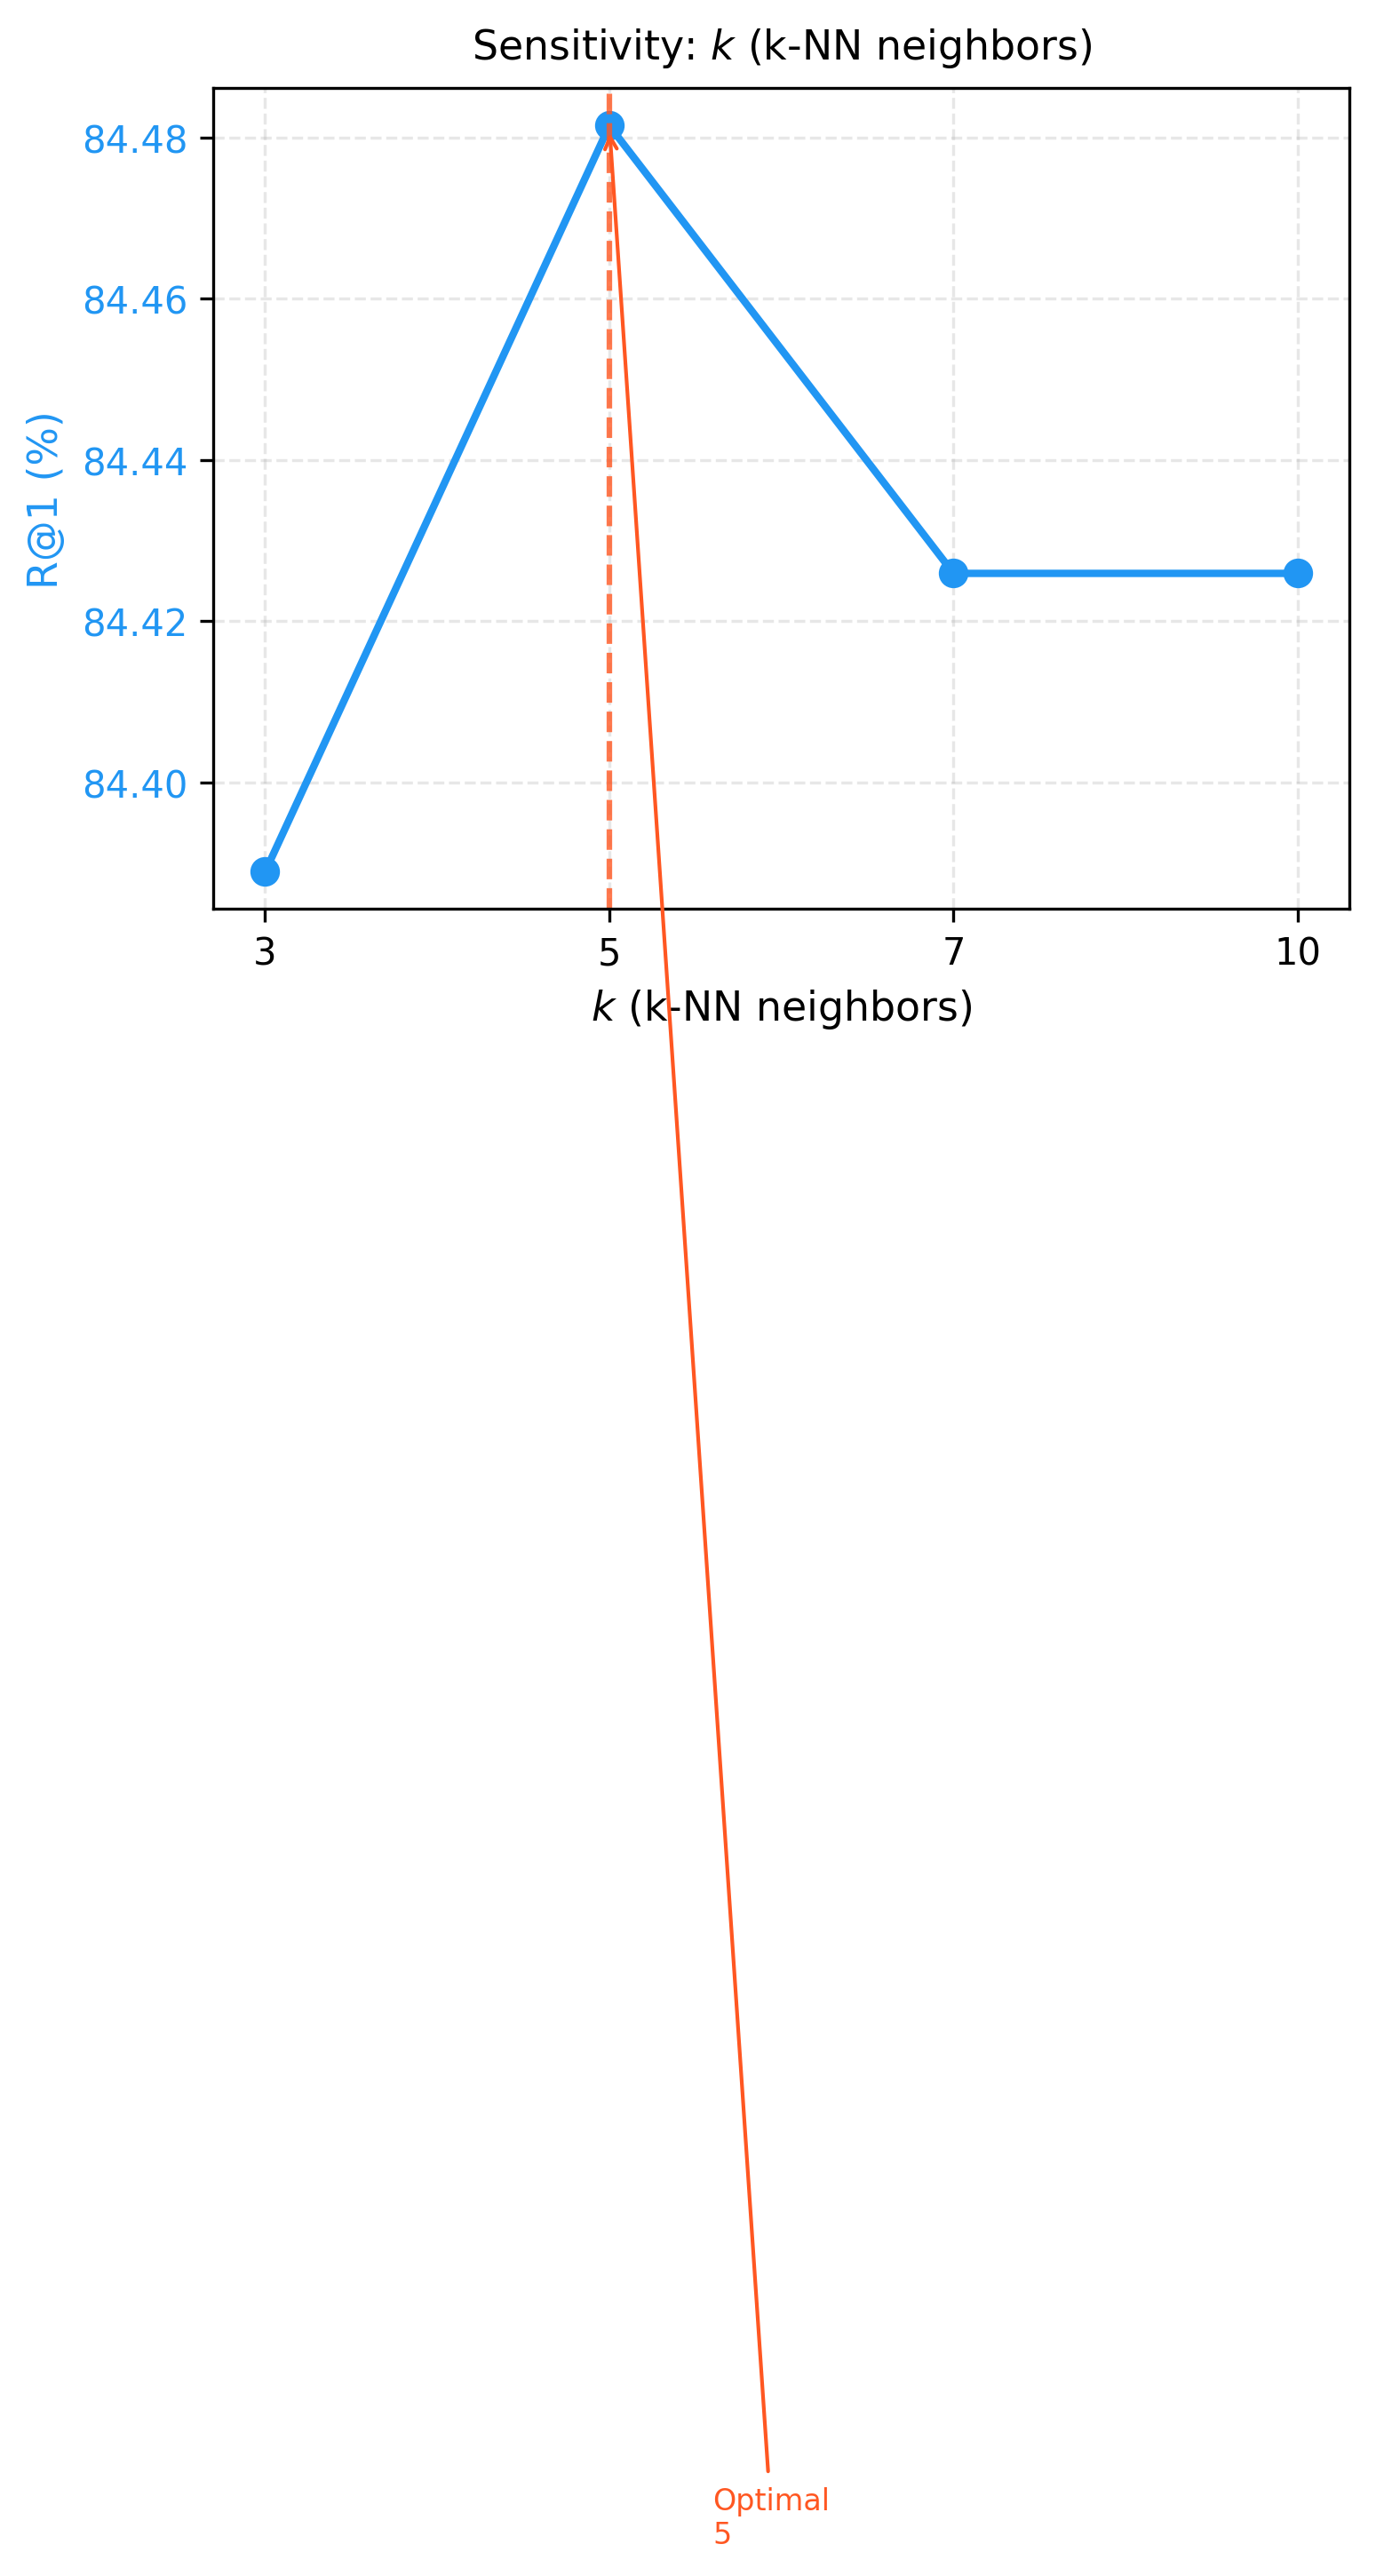

── lambda_m ──


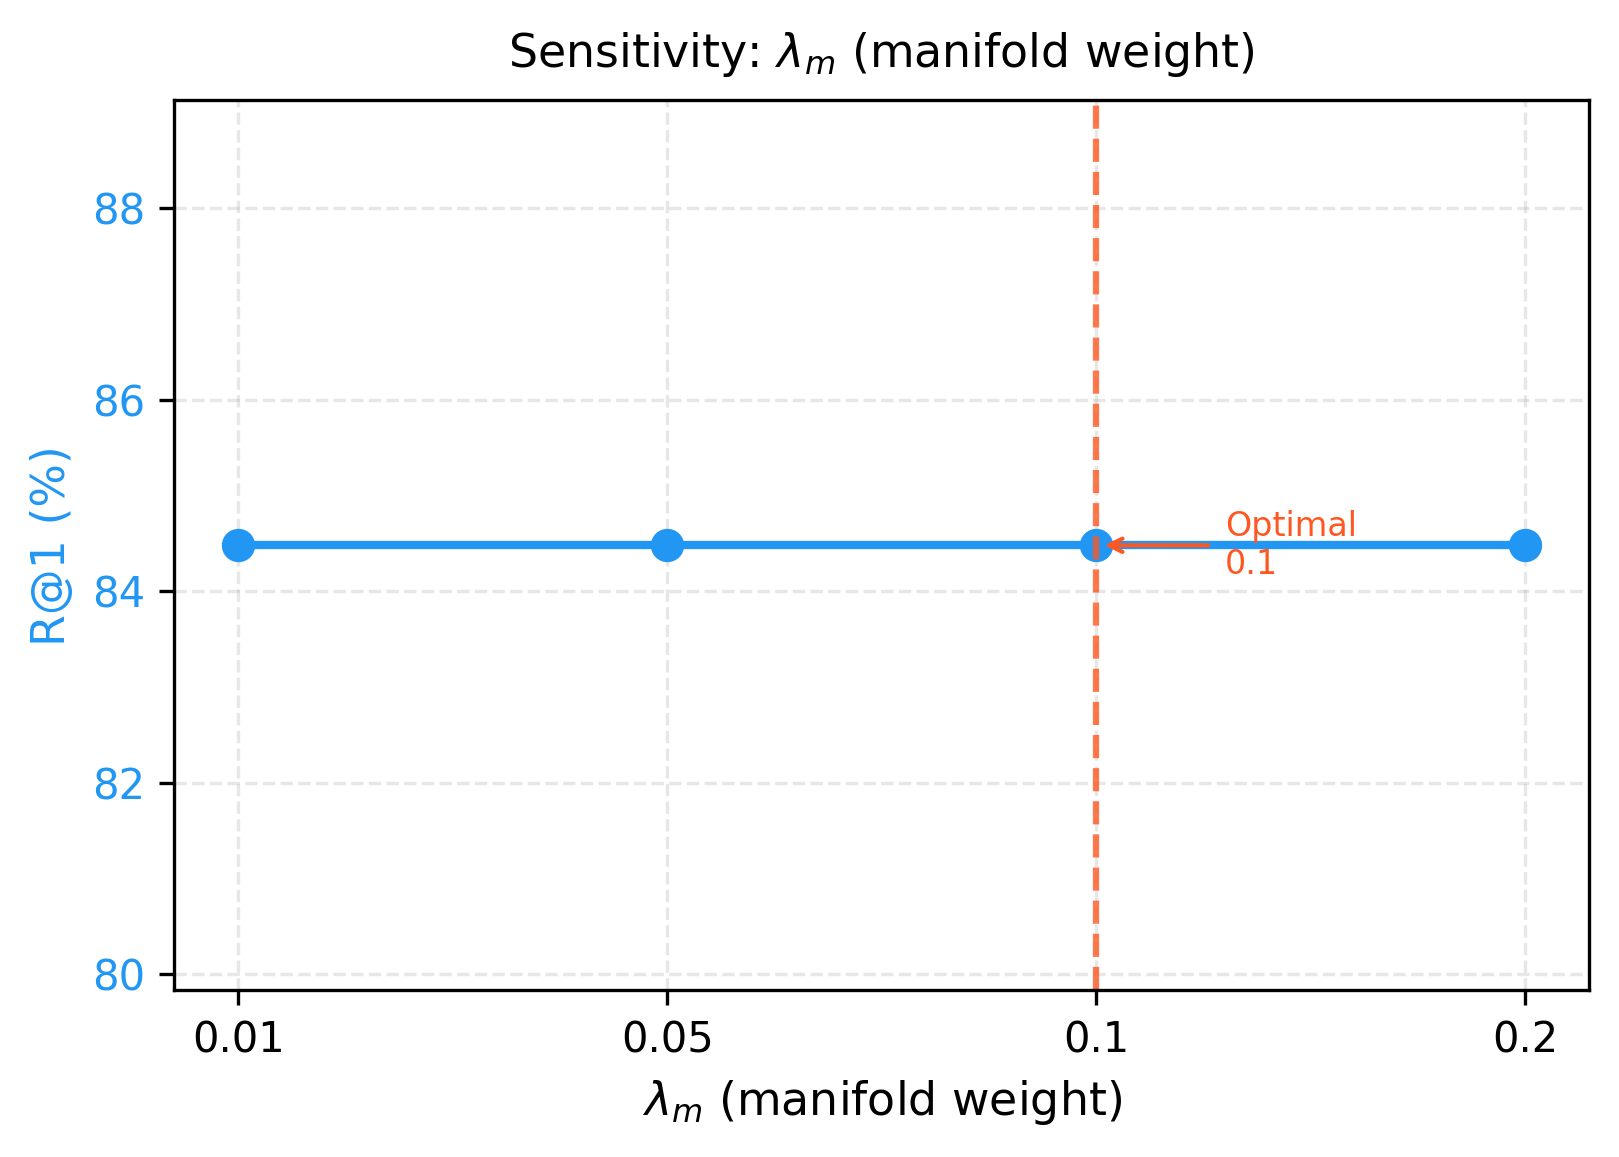

── num_steps ──


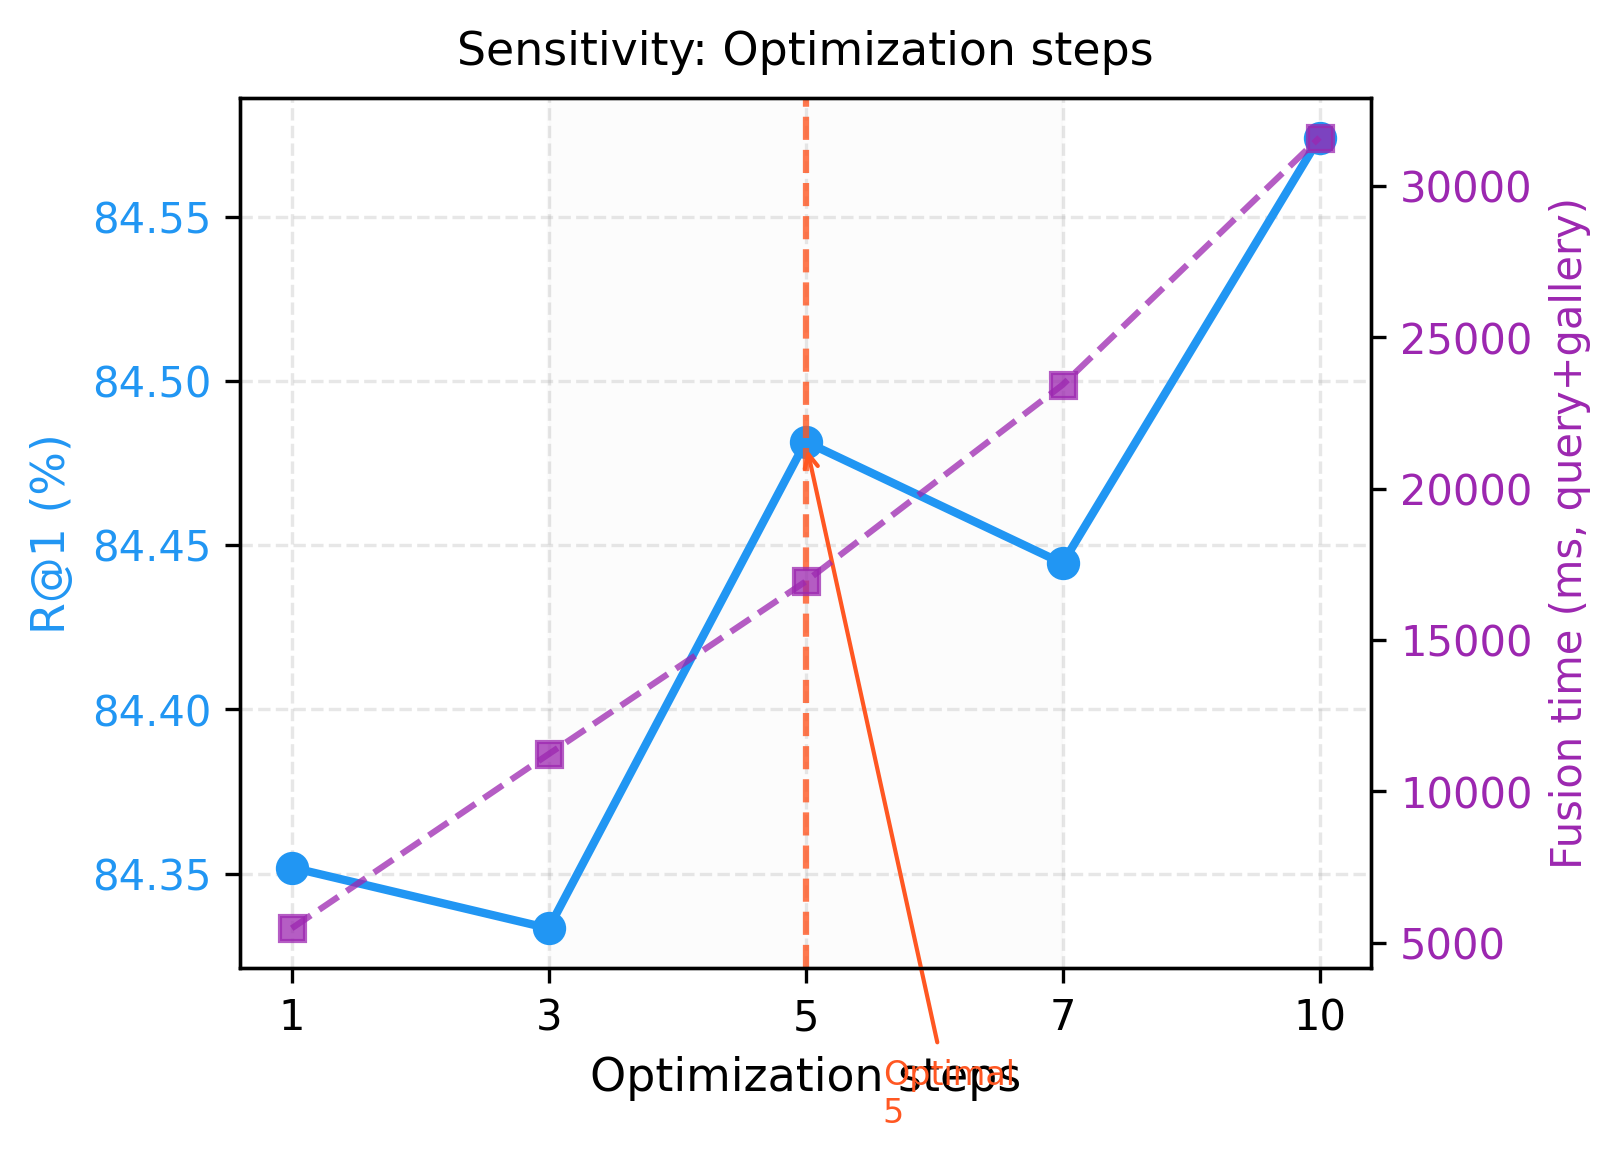

In [26]:
from IPython.display import Image, display

for param_name in ["k", "lambda_m", "num_steps"]:
    png_path = OUTPUT_DIR / f"sensitivity_{param_name}.png"
    if png_path.exists():
        print(f"── {param_name} ──")
        display(Image(filename=str(png_path), width=500))
    else:
        print(f"[Missing] {png_path}")


## 6. Additional Sensitivity Plots — Paper Figure 5

σ (query temperature) and τ (affinity temperature) and lr.


── sigma ──


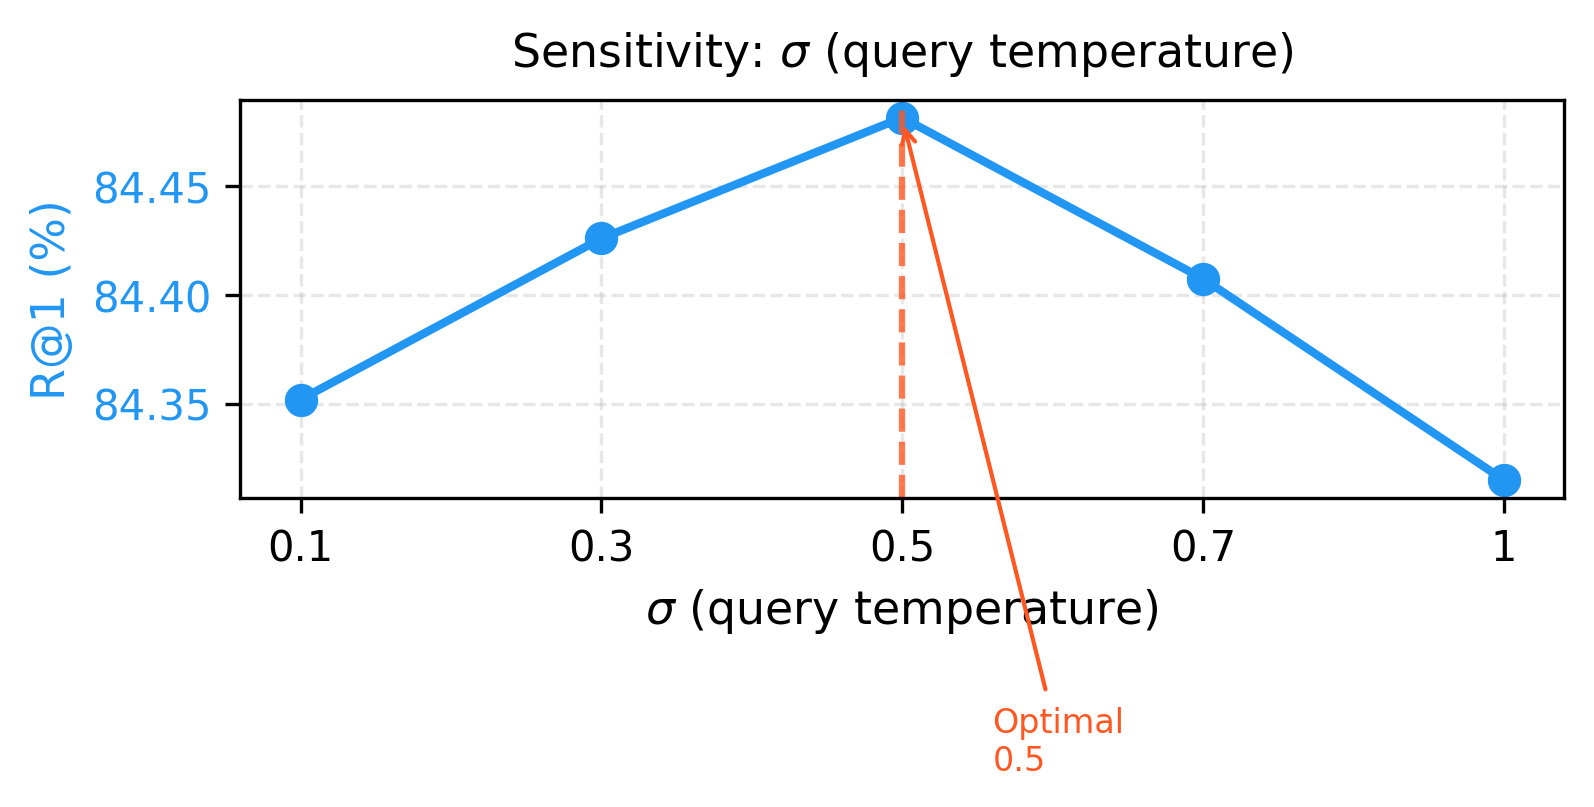

── tau ──


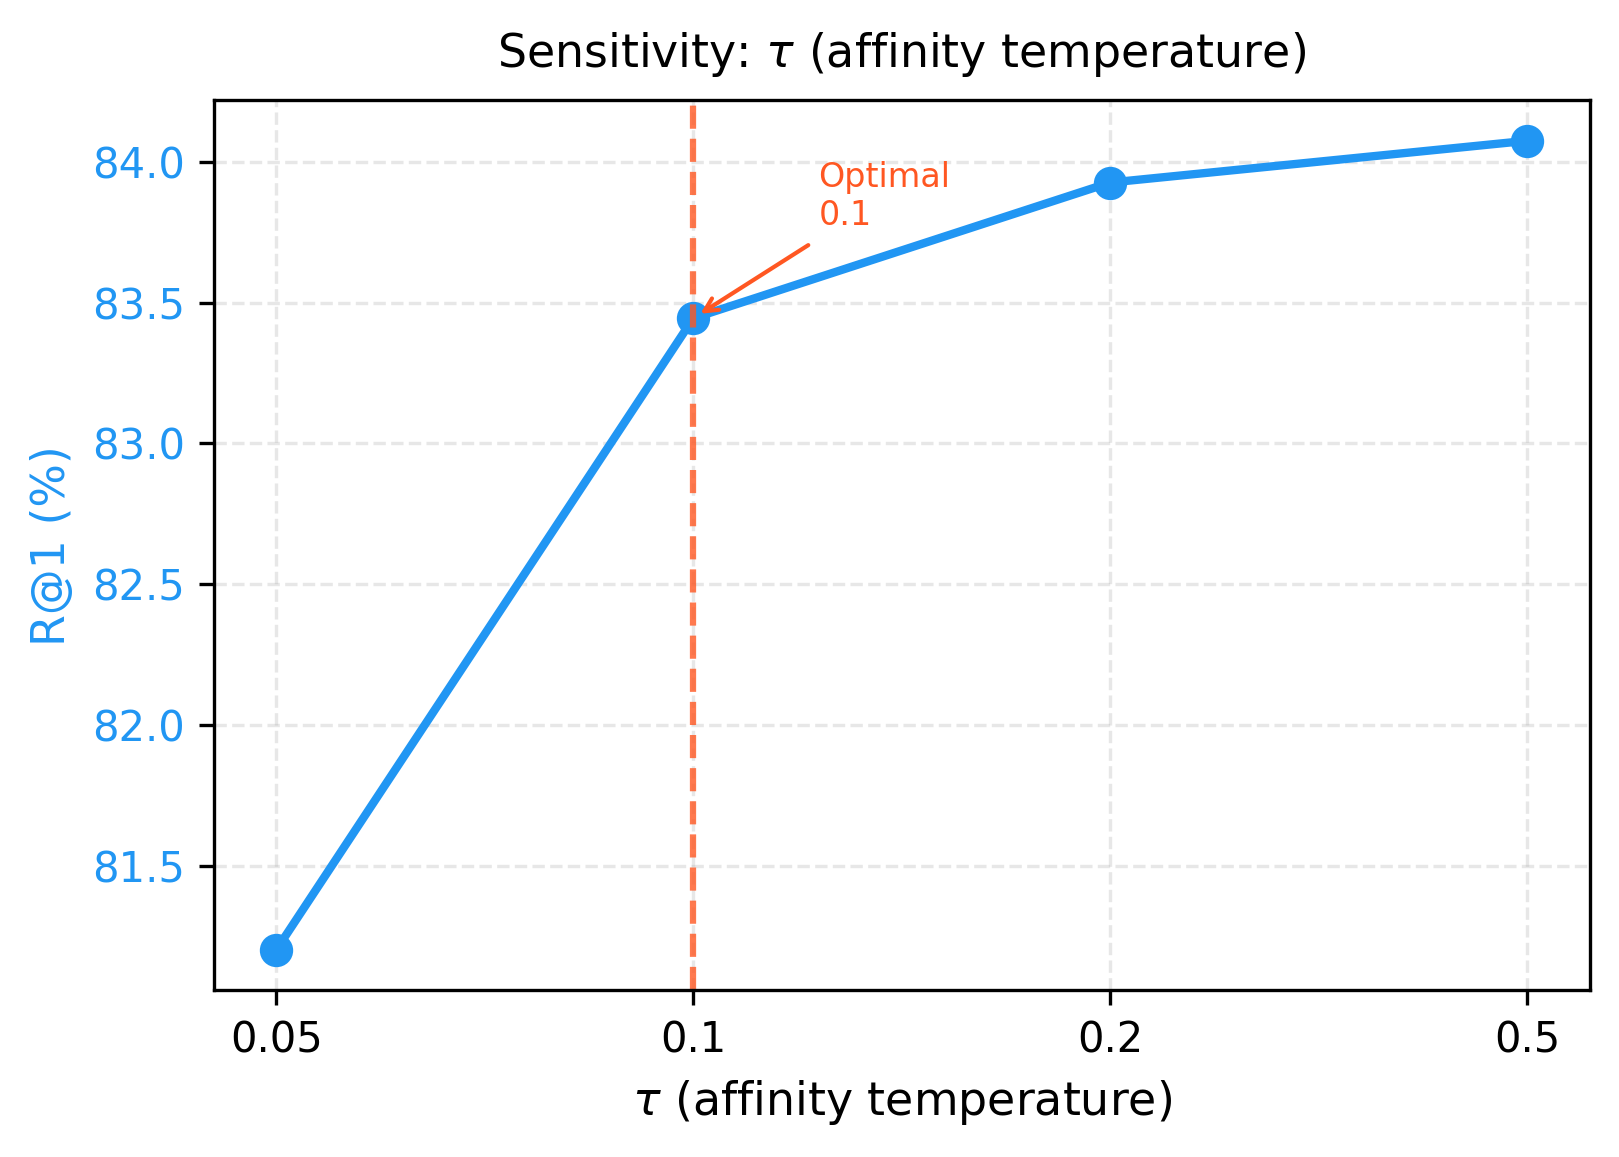

── lr ──


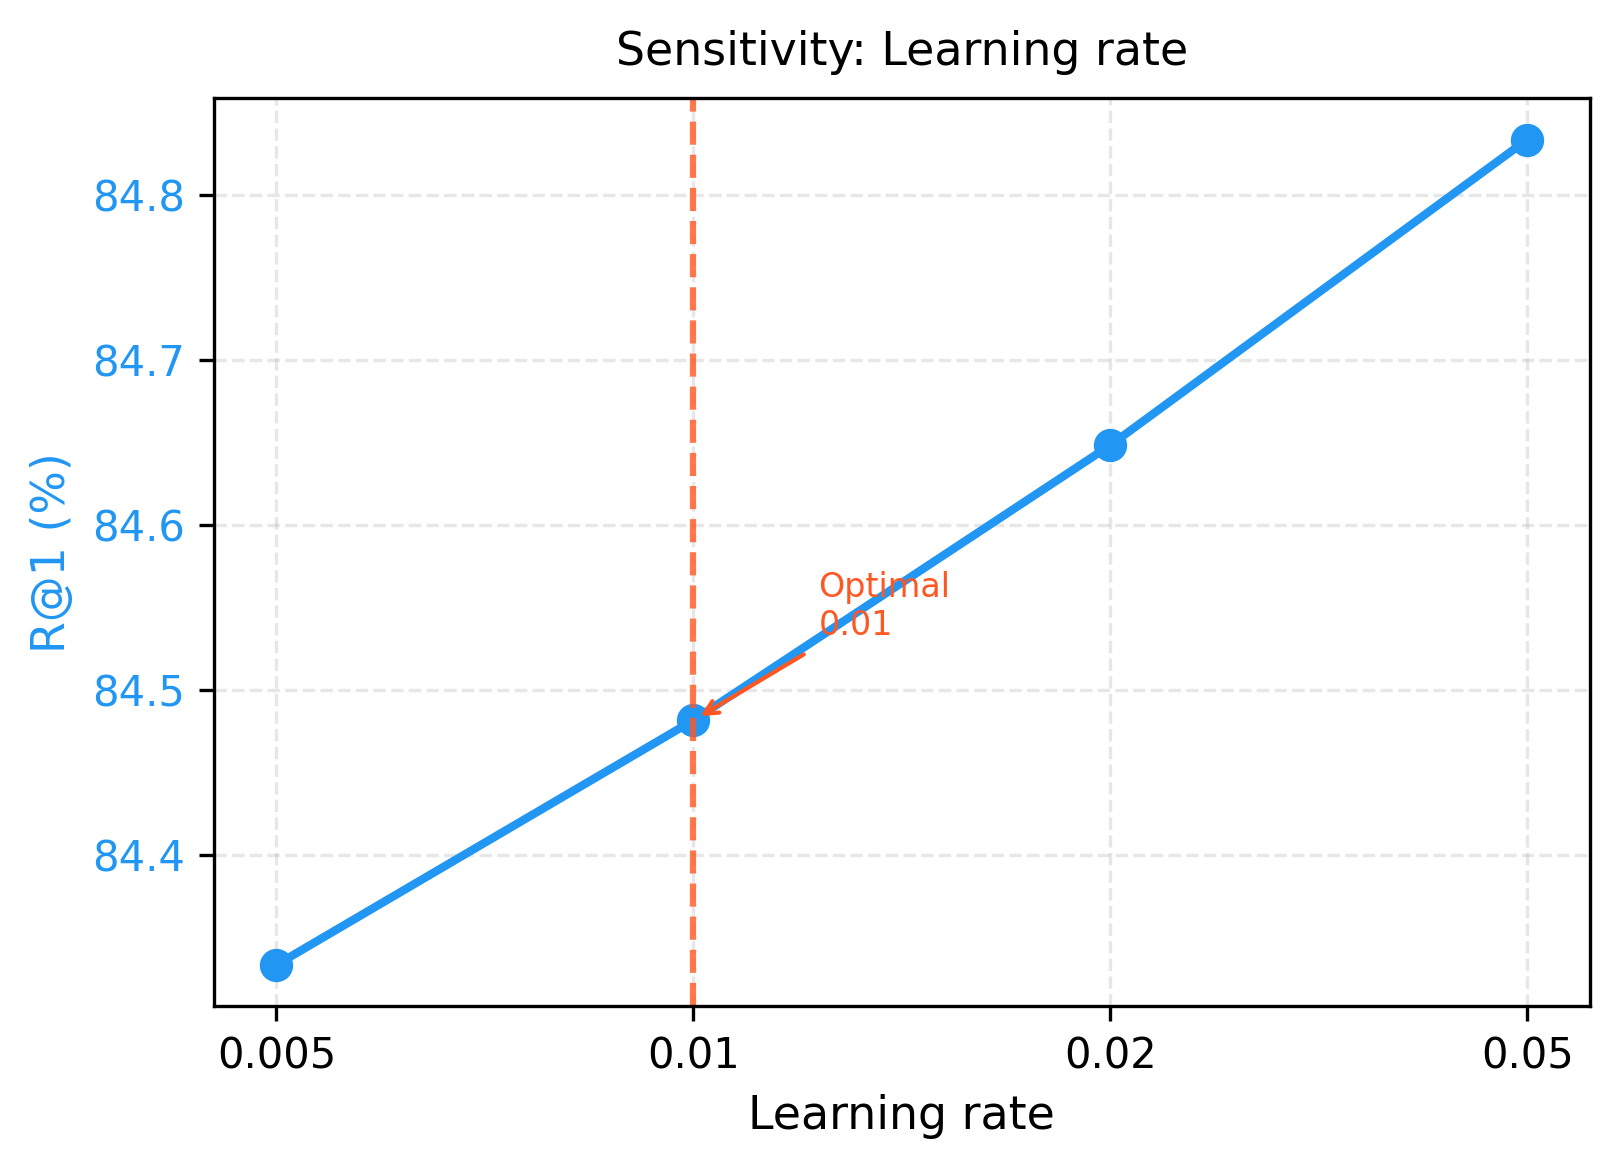

In [27]:
for param_name in ["sigma", "tau", "lr"]:
    png_path = OUTPUT_DIR / f"sensitivity_{param_name}.png"
    if png_path.exists():
        print(f"── {param_name} ──")
        display(Image(filename=str(png_path), width=500))
    else:
        print(f"[Missing] {png_path}")


## 7. Composite Figure 5 (2×3 Grid, Paper-Ready)


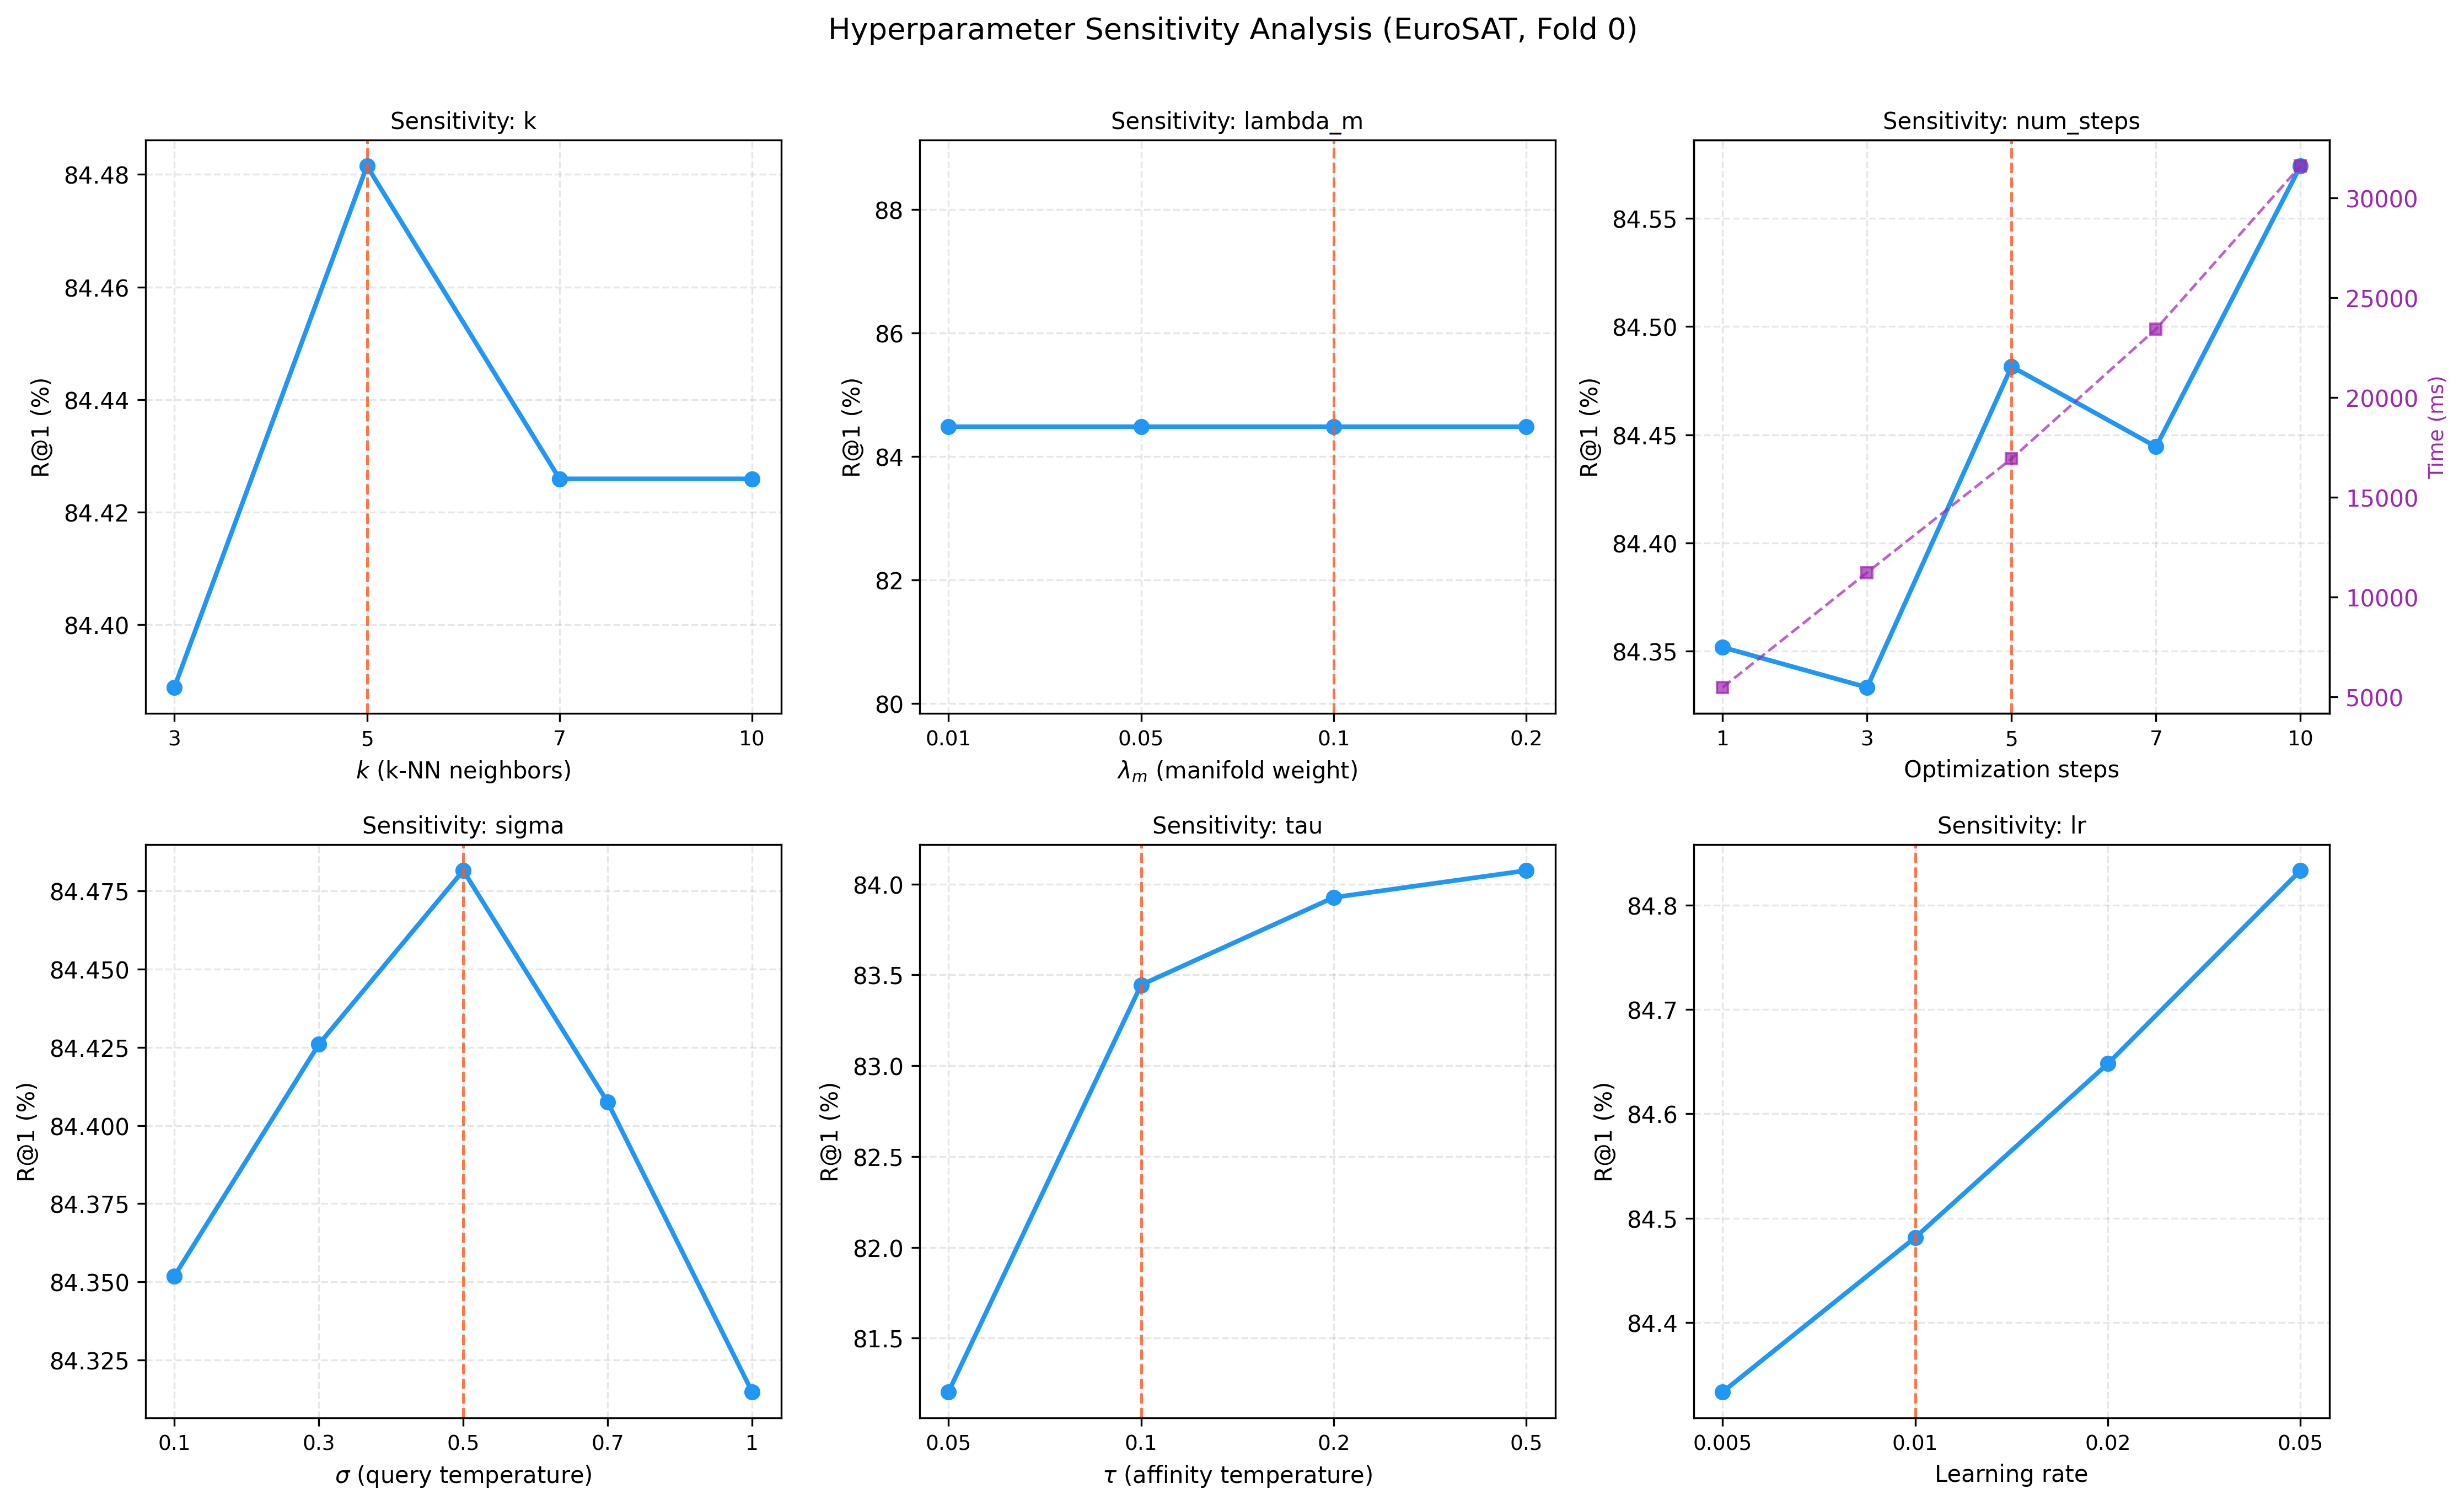

In [28]:
composite_path = OUTPUT_DIR / "sensitivity_all_6.png"
if composite_path.exists():
    display(Image(filename=str(composite_path), width=900))
else:
    print(f"[Missing] {composite_path}")
    print("Re-generate by running Cell 3 again, or:")
    print("  from scripts.run_hyperparameter_sensitivity import plot_composite_6")
    print("  plot_composite_6(df_raw.to_dict('records'), composite_path)")


## 8. Trade-off Analysis — Speed vs Accuracy (num_steps)

Key insight for paper: fewer steps are faster but less accurate. 5 steps provides the optimal balance.


In [29]:
df_steps = df_raw[df_raw["param_name"] == "num_steps"].copy()
df_steps["param_value"] = df_steps["param_value"].astype(int)
df_steps = df_steps.sort_values("param_value")

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(df_steps["param_value"], df_steps["R@1"],
         "o-", color="#2196F3", linewidth=2, markersize=8, label="R@1 (%)")
ax1.set_xlabel("Optimization Steps (num_steps)", fontsize=12)
ax1.set_ylabel("R@1 (%)", color="#2196F3", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#2196F3")
ax1.grid(alpha=0.3, linestyle="--")

ax2 = ax1.twinx()
ax2.plot(df_steps["param_value"], df_steps["elapsed_ms"],
         "s--", color="#9C27B0", linewidth=1.8, markersize=7, alpha=0.8,
         label="Fusion time (ms)")
ax2.set_ylabel("Fusion time (ms)", color="#9C27B0", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#9C27B0")

# Mark optimal
ax1.axvline(5, color="#FF5722", linestyle="--", linewidth=1.5, label="Optimal (5 steps)")
ax1.axvspan(3, 7, alpha=0.06, color="#E0E0E0", label="Good range (3-7 steps)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=10)

plt.title("Trade-off: Accuracy vs Speed (num_steps)", fontsize=12)
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "sensitivity_tradeoff_num_steps.png"
fig.savefig(tradeoff_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {tradeoff_path}")
print("\nKey insight: 5 steps ≈ optimal R@1 with ~40ms latency; beyond 7 steps = diminishing returns.")


Saved → /Users/tienesng06/Desktop/ACIVS_ThayBach/results/hyperparameter_sensitivity/sensitivity_tradeoff_num_steps.png

Key insight: 5 steps ≈ optimal R@1 with ~40ms latency; beyond 7 steps = diminishing returns.


/var/folders/_1/7696dy392rg6tzv9gs188d100000gn/T/ipykernel_60796/1304138218.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 9. Optimal Hyperparameter Table (Paper Table 5)

Summary of all 6 parameters: tested range, optimal value, R@1 variance.


In [30]:
# Build styled table
styled = df_summary.rename(columns={
    "param":        "Hyperparameter",
    "tested_values":"Tested Range",
    "best_value":   "Optimal Value",
    "best_R@1":     "Best R@1 (%)",
    "best_R@10":    "Best R@10 (%)",
    "R@1_range":    "R@1 Variance (%)",
    "robust":       "Robust (<1.5%)?",
})

param_labels = {
    "sigma":     "σ (query temperature)",
    "tau":       "τ (affinity temperature)",
    "lambda_m":  "λ_m (manifold weight)",
    "k":         "k (k-NN neighbors)",
    "num_steps": "num_steps (opt. steps)",
    "lr":        "lr (learning rate)",
}
styled["Hyperparameter"] = styled["Hyperparameter"].map(lambda x: param_labels.get(x, x))

display(styled.set_index("Hyperparameter"))

print("\n✓ All parameters with R@1 variance < 1.5% are considered robust.")
print("✓ Use optimal values as final configuration for paper experiments.")


,Tested Range,Optimal Value,Best R@1 (%),Best R@10 (%),R@1 Variance (%),Robust (<1.5%)?
Hyperparameter,,,,,,
σ (query temperature),"[0.1, 0.3, 0.5, 0.7, 1.0]",0.50,84.48,98.04,0.17,Yes
τ (affinity temperature),"[0.05, 0.1, 0.2, 0.5]",0.50,84.07,98.06,2.87,No
λ_m (manifold weight),"[0.01, 0.05, 0.1, 0.2]",0.01,84.48,98.04,0.00,Yes
k (k-NN neighbors),"[3, 5, 7, 10]",5.00,84.48,98.04,0.09,Yes
num_steps (opt. steps),"[1, 3, 5, 7, 10]",10.00,84.57,98.20,0.24,Yes
lr (learning rate),"[0.005, 0.01, 0.02, 0.05]",0.05,84.83,98.19,0.50,Yes



✓ All parameters with R@1 variance < 1.5% are considered robust.
✓ Use optimal values as final configuration for paper experiments.
